<a href="https://colab.research.google.com/github/ReDanBorn/MathStat/blob/main/2_%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D0%B5_%D1%85%D0%B0%D1%80%D0%B0%D0%BA%D1%82%D0%B5%D1%80%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B8%2C%D0%B2%D0%B8%D0%B7%D1%83%D0%B0%D0%BB%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Практика. Описательные статистики и визуализация данных

**Цели работы:**
- отработать вычисление мер центральной тенденции (среднее, медиана, мода);
- освоить меры изменчивости (размах, дисперсия, стандартное отклонение, коэффициент вариации);
- вычислять квантили, межквартильный размах (IQR), выявлять выбросы;
- интерпретировать показатели формы распределения (асимметрия, эксцесс);
- построить гистограммы, диаграммы размаха (boxplot), сводные таблицы и корректно их интерпретировать.

**Короткий план:**
1) Подготовка окружения  
2) Центральные тенденции (+ ручной расчёт на малом примере)  
3) Размах, дисперсия, стандартное отклонение (+ ручной расчёт)  
4) Квантили и IQR; правило выбросов $1.5\cdot \mathrm{IQR}$ (+ ручной расчёт)  
5) Моменты высших порядков: асимметрия и эксцесс  
6) Визуализация: гистограмма, boxplot, столбчатые диаграммы; сводные таблицы (pivot)  
7) Итоговое мини-задание


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Визуальные параметры (по желанию):
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True

# Учебные данные: встроенный датасет Titanic для примеров с категориальными признаками
df = sns.load_dataset("titanic")

# Маленький числовой массив для ручных расчётов
toy = np.array([2, 4, 4, 5, 100], dtype=float)

df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



## 1. Центральные тенденции: среднее, медиана, мода

### Теория

- **Среднее (выборочное)**:
$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i.
$$
Чувствительно к выбросам: одно экстремальное значение может существенно «утащить» среднее.

- **Медиана** — серединное значение упорядоченного ряда.  
Если $n$ нечётно: $\mathrm{Me} = x_{(\frac{n+1}{2})}$.  
Если $n$ чётно: $\mathrm{Me} = \dfrac{x_{(n/2)} + x_{(n/2+1)}}{2}$.  
Устойчива к выбросам.

- **Мода** — наиболее часто встречающееся значение (возможны несколько мод).

### Ручной расчёт (набор `toy = [2, 4, 4, 5, 100]`)
Упорядоченный ряд: $[2,\; 4,\; 4,\; 5,\; 100]$.  
$\bar{x}=(2+4+4+5+100)/5=115/5=23$.  
$\mathrm{Me}=4$ (середина ряда).  
$\mathrm{Mo}=4$ (встречается чаще всего).  
Вывод: среднее смещено вправо из-за выброса $100$; медиана/мода отражают «массу» наблюдений.


In [ ]:

data = toy.copy()

# Среднее и медиана
mean_ = np.mean(data)           # среднее арифметическое
median_ = np.median(data)       # медиана

# Мода из scipy.stats
mode_res = stats.mode(data, keepdims=True)
mode_ = mode_res.mode[0]
mode_count = mode_res.count[0]

print(f"Данные: {data.tolist()}")
print(f"Среднее:  {mean_: .3f}")
print(f"Медиана:  {median_: .3f}")
print(f"Мода:     {mode_: .3f} (частота {int(mode_count)})")

Данные: [2.0, 4.0, 4.0, 5.0, 100.0]
Среднее:   23.000
Медиана:   4.000
Мода:      4.000 (частота 2)



## 2. Меры изменчивости: размах, дисперсия, стандартное отклонение

### Теория
- **Размах**:
$$
R = x_{\max} - x_{\min}.
$$
- **Дисперсия (выборочная, несмещённая)**:
$$
s^2 = \frac{1}{n-1}\sum_{i=1}^{n} (x_i - \bar{x})^2.
$$
- **Стандартное отклонение**:
$$
s = \sqrt{s^2}.
$$

**Замечания:**
- Деление на $n-1$ компенсирует систематическое занижение разброса в выборке относительно генеральной совокупности (несмещённость).
- Единицы измерения: дисперсия — «в квадрате» исходной величины; стандартное отклонение — в тех же единицах, что и наблюдения.

### Ручной расчёт (тот же `toy`)
$\bar{x}=23$. Отклонения и их квадраты:  
$(2-23)^2=441,\;(4-23)^2=361,\;(4-23)^2=361,\;(5-23)^2=324,\;(100-23)^2=5929$.  
Сумма квадратов отклонений: $= 441+361+361+324+5929 = 7416$.  
$s^2 = 7416/(5-1) = 1854$.  
$s = \sqrt{1854} \approx 43.053$.


In [ ]:
data = toy.copy()
R = data.max() - data.min()        # размах
var_sample = np.var(data, ddof=1)  # выборочная дисперсия
std_sample = np.std(data, ddof=1)  # выборочное СКО

print(f"Размах R: {R: .3f}")
print(f"Дисперсия s^2 (ddof=1): {var_sample: .3f}")
print(f"СКО s (ddof=1): {std_sample: .3f}")


Размах R:  98.000
Дисперсия s^2 (ddof=1):  1854.000
СКО s (ddof=1):  43.058



## 3. Квантили, процентилли и межквартильный размах (IQR). Выбросы

### Теория
- $Q_1$ — 25-й процентиль, $Q_2$ — медиана (50-й), $Q_3$ — 75-й.  
- **IQR**:
$$
\mathrm{IQR} = Q_3 - Q_1.
$$
- **Правило «1.5·IQR» для выбросов**:
$$
\text{нижняя граница} = Q_1 - 1.5\cdot \mathrm{IQR}, \qquad
\text{верхняя граница} = Q_3 + 1.5\cdot \mathrm{IQR}.
$$

### Ручной расчёт (тот же `toy`)
Упорядоченный ряд: $[2, 4, 4, 5, 100]$.  
$Q_1=4,\; Q_2=4,\; Q_3=5$.  
$\mathrm{IQR}=1$.  
Границы: нижняя $= 2.5$; верхняя $= 6.5$.  
Значения $2$ и  $100$ — выбросы.


In [ ]:

data = toy.copy()

# Расчет квантилей и IQR
q1 = np.percentile(data, 25)
q2 = np.percentile(data, 50)   # медиана
q3 = np.percentile(data, 75)
iqr = q3 - q1

# Расчет границ ящика
low  = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

# Расчет выборосов
outliers = data[(data < low) | (data > high)]

print(f"Q1={q1:.3f}, Q2={q2:.3f}, Q3={q3:.3f}, IQR={iqr:.3f}")
print(f"Границы выбросов: [{low:.3f}, {high:.3f}]")
print(f"Выбросы: {outliers.tolist() if outliers.size else 'нет'}")


Q1=4.000, Q2=4.000, Q3=5.000, IQR=1.000
Границы выбросов: [2.500, 6.500]
Выбросы: [2.0, 100.0]


Базовые описательные статистики для числовых факторов можно получить используя базовый метод pandas с помощью df.describe() для набора данных df.
Данный способ позволяет для числовых факторов оценить:

- количество значений без пропусков в столбце фактора
- среднее арифметическое по столбцу фактора
- среднеквадратическое отклонение по столбцу фактора
- минимальное и максимальное выборочное значение по столбцу
- стандартные выборочные квартили ($Q_1, Q_2, Q_3$), где $Q_2$ - медиана


In [ ]:
df.describe().round(2)

,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


Таким образом можно оценить определенные особенности таблицы данных, например:
- в столбце `age` пропущено 177 значений
- столбцы `survived`, `pclass`, `sibsp`, `parch` - возможно порядковые, целочисленные и дискретные, обозначающие градирующую категорию или бинарный фактор
- максимальный возраст в выборке - 80 лет, минимальный 5 месяцев
- в столбце `fare` возможны нетипичные значения за пределами $Q_1-1.5\cdot IQR$ и $Q_3+1.5\cdot IQR$



## 4. Форма распределения: асимметрия и эксцесс

### Теория (в выборочных оценках)
- **Асимметрия (скошенность)**:
$$
\mathrm{As} = \frac{\frac{1}{n}\sum_{i=1}^{n} (x_i-\bar{x})^3}{s^3}.
$$
$\mathrm{As}>0$ — «хвост» вправо; $\mathrm{As}<0$ — «хвост» влево.

- **Эксцесс (островершинность относительно нормального закона)**:
$$
\mathrm{Ex} = \frac{\frac{1}{n}\sum_{i=1}^{n} (x_i-\bar{x})^4}{s^4} - 3.
$$
$\mathrm{Ex}>0$ — острее, чем нормальное; $\mathrm{Ex}<0$ — более плоское.

**Интерпретация:** для нормального распределения $\mathrm{As}\approx 0$, $\mathrm{Ex}\approx 0$ (в выборке — «близко к нулю» с учётом разброса).


In [ ]:
data = toy.copy()

# Параметры bias=False используют скорректированные варианты оценок
skew_ = stats.skew(data, bias=False)
kurt_ = stats.kurtosis(data, bias=False)  # по умолчанию excess (вычитает 3)

print(f"Асимметрия (skewness): {skew_: .3f}")
print(f"Эксцесс (kurtosis, excess): {kurt_: .3f}")

Асимметрия (skewness):  2.232
Эксцесс (kurtosis, excess):  4.987


In [ ]:
data = df['age']

# Параметр nan_policy='omit' позволяют не использовать в вычислении пропуски
skew_ = stats.skew(data, bias=False, nan_policy='omit')
kurt_ = stats.kurtosis(data, bias=False, nan_policy='omit')  # по умолчанию excess (вычитает 3)

print(f"Асимметрия (skewness): {skew_: .3f}")
print(f"Эксцесс (kurtosis, excess): {kurt_: .3f}")

Асимметрия (skewness):  0.389
Эксцесс (kurtosis, excess):  0.178



## 5. Визуализация количественных и категориальных данных

### 5.1. Гистограмма и оценка плотности
Гистограмма показывает частотное распределение; наложение гладкой кривой плотности (ядровая оценка) помогает визуально оценить форму.


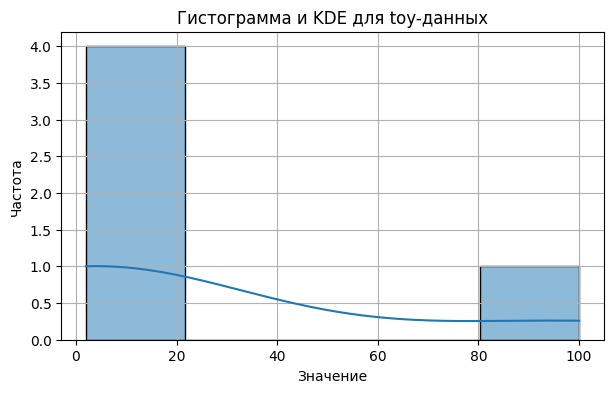

In [ ]:

data = toy.copy()

sns.histplot(data, bins=5, kde=True)
plt.title("Гистограмма и KDE для toy-данных")
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.show()


Для визуализации отдельных факторов мы можем использовать отдельные столбцы наборов данных pandas через обращение к ним как к индексам столбцов по имени, например

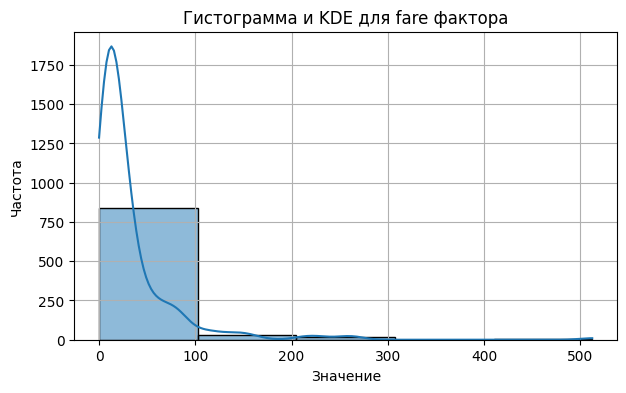

In [ ]:
data_col = df['fare']

sns.histplot(data_col, bins=5, kde=True)
plt.title("Гистограмма и KDE для fare фактора")
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.show()

По гистограмме выше видим, что количество разбиений исходного ряда не помогает понять внутренней структуры распределения. Для вычисления числа столбцов воспользуемся правилом Стёрджесса:

$$bins = 1 + \lfloor log_2(N) \rfloor$$

где N - число записей в таблице данных


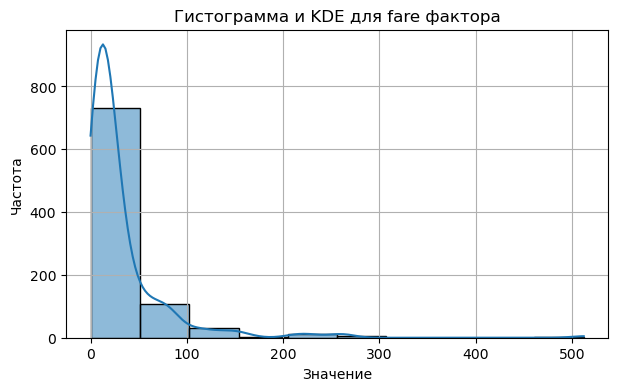

In [ ]:
data_col = df['fare']

N = len(data_col)       # Длина итерируемого объекта
N = data_col.shape[0]   # Значение для первой размерности np.ndarray

sns.histplot(data_col, bins=1 + int(np.log2(N)), kde=True)
plt.title("Гистограмма и KDE для fare фактора")
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.show()

Данная визуализация позволяет отобразить провал в количестве наблюдений при диапазоне $[150,200]$. Разница в частотах не значительна относительно общего количества наблюдений, данный эффект нужно подтверждать только на более репрезентативной выборке.

Распределение данных фактора `fare` далее можно тестировать на логнормальное/экспоненциальное распределение.

**Далее рассмотрим распределение данных по возрастам**

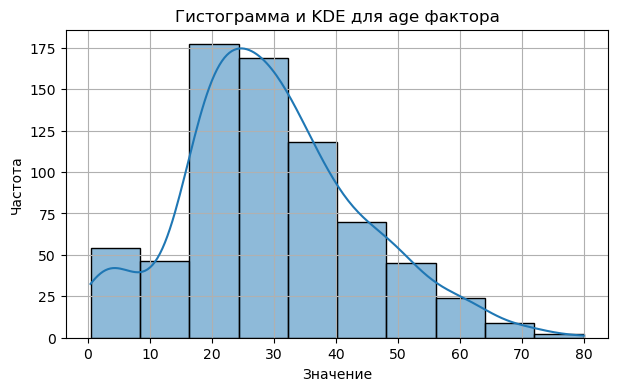

In [ ]:
data_col = df['age']

N = len(data_col)       # Длина итерируемого объекта

sns.histplot(data_col, bins=1 + int(np.log2(N)), kde=True)
plt.title("Гистограмма и KDE для age фактора")
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.show()

Наблюдаем колоколообразную скошенную форму распределения. Можно тестировать данное распределение на нормальность или логнормальность. Также возможна ситуация, где данное распределение является смесью распределний по данным с разными значениями категорий.

Рассмотрим ситуацию, где данные `age` распределены по различным целевым значениям, чтобы узнать его информативность при решении задач естественной классификации.

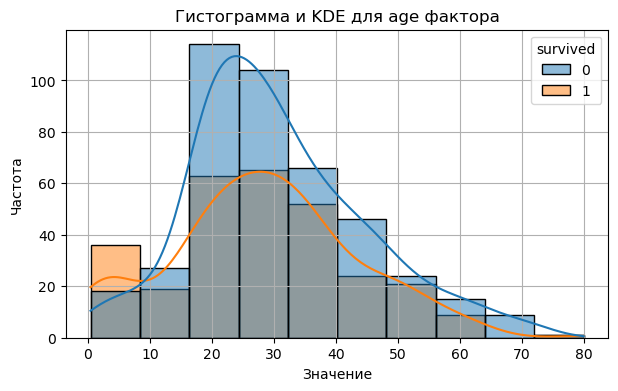

In [ ]:
N = len(df)       # Длина итерируемого объекта

sns.histplot(data=df, x='age', bins=1 + int(np.log2(N)), hue = 'survived', kde=True)
plt.title("Гистограмма и KDE для age фактора")
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.show()

Детализация по данной категории показывает, что возраст не является информативным при дискриминации объектов на заданном категориальом факторе в выборке данных.

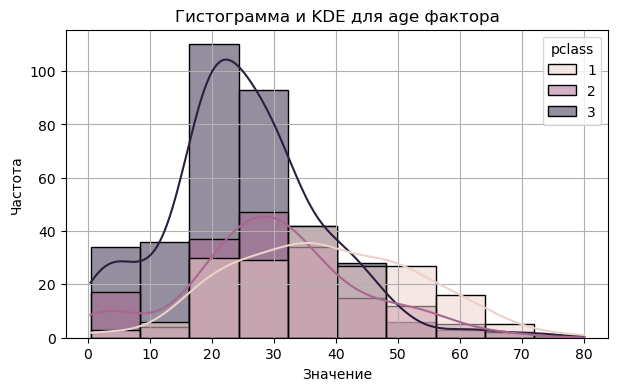

In [ ]:
N = len(df)       # Длина итерируемого объекта

sns.histplot(data=df, x='age', bins=1 + int(np.log2(N)), hue = 'pclass', kde=True)
plt.title("Гистограмма и KDE для age фактора")
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.show()


### 5.2. Диаграмма размаха (boxplot)
Boxplot визуализирует $Q_1$, медиану $Q_2$, $Q_3$, усы и выбросы (как правило, по правилу $1.5\cdot \mathrm{IQR}$).


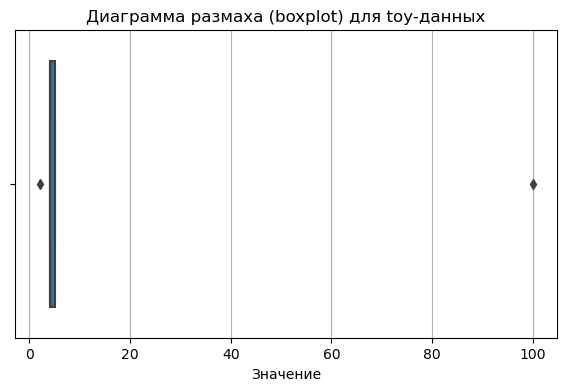

In [ ]:

sns.boxplot(x=data)
plt.title("Диаграмма размаха (boxplot) для toy-данных")
plt.xlabel("Значение")
plt.show()


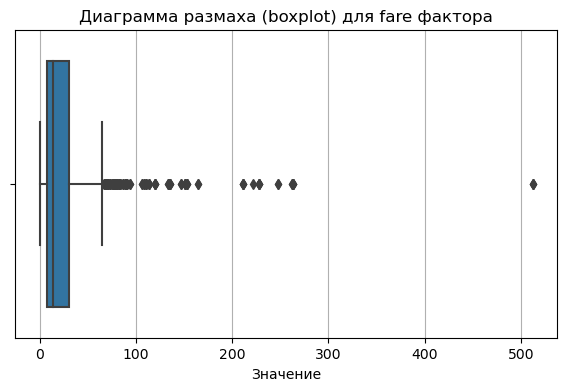

In [ ]:
sns.boxplot(data = df, x='fare')
plt.title("Диаграмма размаха (boxplot) для fare фактора")
plt.xlabel("Значение")
plt.show()


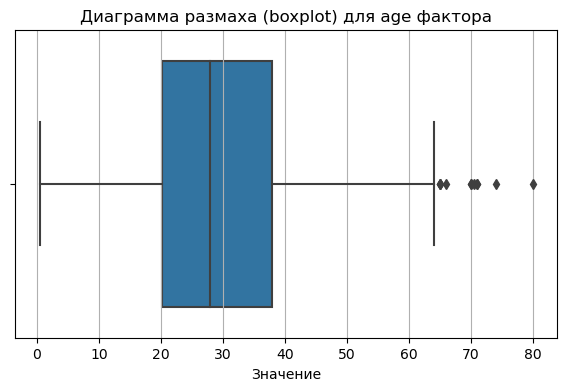

In [ ]:
sns.boxplot(data = df, x='age')
plt.title("Диаграмма размаха (boxplot) для age фактора")
plt.xlabel("Значение")
plt.show()

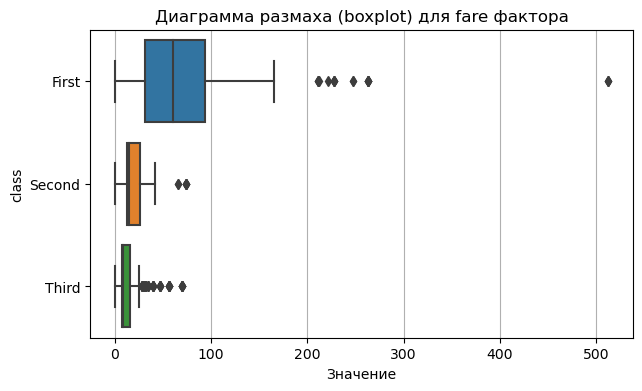

In [ ]:
sns.boxplot(data=df, x='fare', y="class")
plt.title("Диаграмма размаха (boxplot) для fare фактора")
plt.xlabel("Значение")
plt.show()

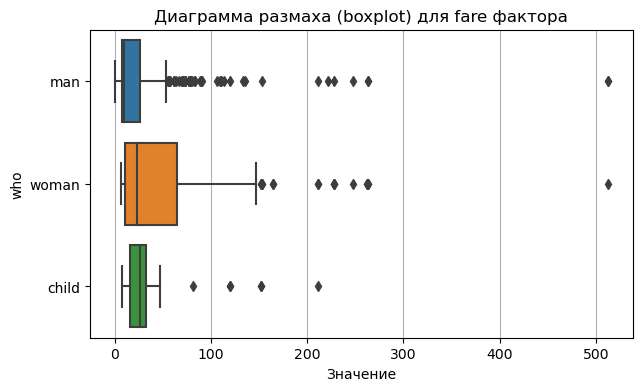

In [ ]:
sns.boxplot(data=df, x='fare', y="who")
plt.title("Диаграмма размаха (boxplot) для fare фактора")
plt.xlabel("Значение")
plt.show()


### 5.3. Сводные таблицы (pivot) и столбчатые диаграммы

На категориальных данных удобно считать доли/средние внутри групп.  
Пример: доля выживших на «Титанике» по полу и классу.


Сводная таблица (доля выживших):


class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


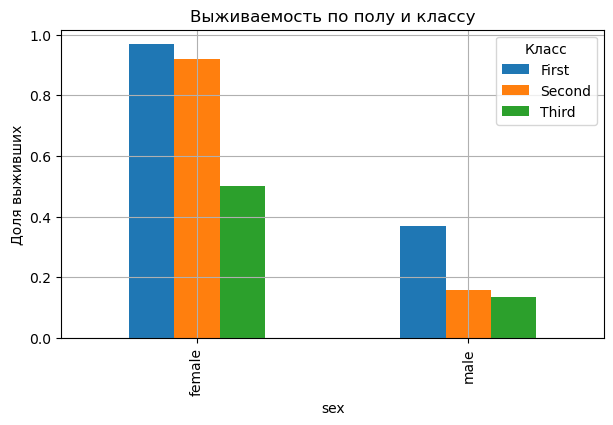

In [ ]:

pivot = pd.pivot_table(
    df,
    values="survived",      # среднее по бинарной переменной = доля (0/1)
    index="sex",
    columns="class",
    aggfunc=np.mean
)

print("Сводная таблица (доля выживших):")
display(pivot)

ax = pivot.plot(kind="bar")
ax.set_title("Выживаемость по полу и классу")
ax.set_ylabel("Доля выживших")
ax.legend(title="Класс")
plt.show()



## 6. Дополнение: коэффициент вариации и робастные альтернативы

- **Коэффициент вариации** (сравнение относительного разброса):
$$
\mathrm{CV} = \frac{s}{\bar{x}}\times 100\% .
$$
Корректно сравнивать CV у переменных в одинаковых единицах и при $\bar{x}>0$.

- **Робастные альтернативы**:
  - вместо среднего — медиана;
  - вместо стандартного отклонения — $ \mathrm{IQR} / 1.349 $ (для приблизимой шкалы «в единицах σ» при нормальности).


In [ ]:

data = toy.copy()

mean_ = np.mean(data)
std_  = np.std(data, ddof=1)
cv = (std_ / mean_) * 100 if mean_ != 0 else np.nan

q1, q3 = np.percentile(data, [25, 75])
iqr = q3 - q1
sigma_robust = iqr / 1.349  # эквивалентное "σ" для нормального закона

print(f"Среднее = {mean_:.3f}, СКО = {std_:.3f}, CV = {cv:.2f}%")
print(f"IQR = {iqr:.3f}, робастная 'σ' ≈ {sigma_robust:.3f}")


Среднее = 23.000, СКО = 43.058, CV = 187.21%
IQR = 1.000, робастная 'σ' ≈ 0.741



## 7. Мини-задание (самостоятельная работа)

Возьмите набор из 10–15 наблюдений (например, рост в см):
$$
x = [170, 165, 180, 175, 190, 200, 300, 178, 172, 169, 185, 176]
$$

**Требуется:**
1. Вычислить $\bar{x}$, медиану, и первую моду.  
2. Найти размах, выборочную дисперсию, СКО, коэффициент вариации.  
3. Рассчитать $Q_1, Q_2, Q_3$, IQR; определить выбросы по правилу $1.5\cdot\mathrm{IQR}$.  
4. Построить гистограмму и boxplot; кратко интерпретировать (скошенность, наличие выбросов).  
5. Сформировать сводную таблицу для любой категориальной разбивки, если таковая имеется (или самостоятельно выделить группы по произвольному порогу и оценить доли).


### **Выполнение:**

1. Определение массива данных

In [ ]:
# Ваш код для определения переменной с данными (np.ndarray, pandas series или list)

2. Определение центральной тенденции ряда

In [ ]:
# Код для расчета среднего, медианы и первой моды данных

3. Определение изменчивости данных

In [ ]:
# Ваш код для расчета дисперсии, стандартного отклонения, коэффициента вариации

4. Квантили, IQR и выбросы

In [ ]:
# Ваш код для определения квантилей, IQR и списка с выбросами из набора данных по ящику с усами

5. Визуализация и отображение гистограммы и ящика с усами (boxplot) на ряде данных

In [ ]:
# Ваш код здесь

6. Текстовый вывод основных метрик в виде отчета

In [ ]:
# Ваш код текстового вывода здесь